In [1]:
import pandas as pd
from src.assay_calibration.fit_utils.fit import Fit
from src.assay_calibration.data_utils.dataset import Scoreset
from src.assay_calibration.fit_utils.two_sample import (density_utils,constraints)
import numpy as np
import matplotlib.pyplot as plt

DEBUG:matplotlib:matplotlib data path: /home/dzeiberg/miniconda3/envs/pillar_project/lib/python3.10/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/home/dzeiberg/.config/matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is linux
DEBUG:matplotlib:CACHEDIR=/home/dzeiberg/.cache/matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /home/dzeiberg/.cache/matplotlib/fontlist-v390.json


In [2]:
pillar_df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv.tar.gz")

/tmp/ipykernel_1684448/2556373638.py:1: DtypeWarning: Columns (4,11,22,23,24,31,35,36,37,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,57,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  pillar_df = pd.read_csv("/data/dzeiberg/pillar_project/pillar_project_data/dataset_09192025/final_pillar_data_with_clinvar_gnomad_wREVEL_wAM_wspliceAI_wMutpred2_wtrainvar_expanded_091125.csv.tar.gz")


In [3]:
scoreset = Scoreset(pillar_df[pillar_df.Dataset == 'DDX3X_Radford_2023_cLFC_day15'],population_type='all_variants')

In [4]:
fit = Fit(scoreset)

In [5]:
job = fit.generate_fit_jobs([2,3],bootstrap=False, check_monotonic=True)

In [6]:
job[1]['save_dir'] = "test/test_fits"
job[1]['dataset_name'] = "DDX3X"

In [7]:
Fit.execute_fit_job(job[1])

In [8]:
ls test/test_fits/

DDX3X_bNone_c3_f0.pkl


In [9]:
import joblib
fit_result = joblib.load("test/test_fits/DDX3X_bNone_c3_f0.pkl")

In [10]:
fit_result['fit']

{'component_params': [(-2.7476077680885784,
   -2.3353538569902,
   0.6903965032480481),
  (-1.0460106682906645, -0.13764419598020594, 0.18298480229873818),
  (179.84123936328245, 0.08788327723752151, 0.1077001544345826)],
 'weights': array([[7.13643964e-001, 1.96460041e-001, 8.98959954e-002],
        [1.71863281e-133, 8.31689839e-001, 1.68310161e-001],
        [2.03665988e-003, 7.31764467e-001, 2.66198873e-001],
        [1.60640656e-003, 7.85792931e-001, 2.12600662e-001]]),
 'likelihoods': array([-0.91136278, -0.77169145, -0.74176871, -0.74086453, -0.74061854,
        -0.74061649, -0.74061649]),
 'history': [{'component_params': [[-3.1127803770057114,
     -2.4035560588273377,
     0.7719848410633764],
    [-1.065931583804033, -0.15652408859742117, 0.1848137697320792],
    [179.8412393640237, 0.08788327723752151, 0.1077001544345826]],
   'weights': array([[6.96991393e-01, 2.12716878e-01, 9.02917289e-02],
          [1.27935509e-20, 8.18248949e-01, 1.81751051e-01],
          [2.03665988

In [13]:
fit_result['fit']['weights']

array([[7.13643964e-001, 1.96460041e-001, 8.98959954e-002],
       [1.71863281e-133, 8.31689839e-001, 1.68310161e-001],
       [2.03665988e-003, 7.31764467e-001, 2.66198873e-001],
       [1.60640656e-003, 7.85792931e-001, 2.12600662e-001]])

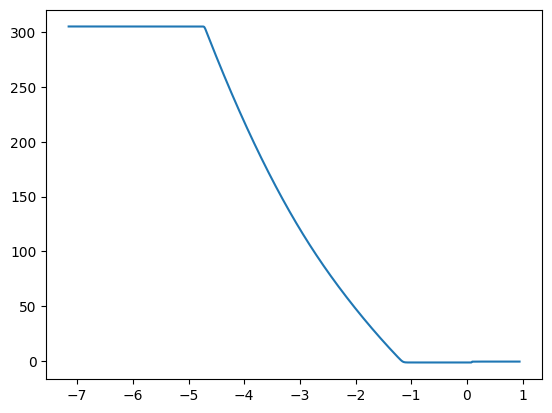

In [ ]:
score_range = np.linspace(*np.percentile(scoreset.scores,[0,100]),1000)
log_fPath = density_utils.mixture_pdf(score_range,
                                      fit_result['fit']['component_params'],
                                      fit_result['fit']['weights'][0])
log_fBenign = density_utils.mixture_pdf(score_range,
                                      fit_result['fit']['component_params'],
                                      fit_result['fit']['weights'][1])
plt.plot(score_range, log_fPath - log_fBenign)
